# Lecture 2 — Transfer Learning & Fine-Tuning with ResNet-34

In Lecture 1 we built and trained a small custom CNN from scratch on the **Weather Image
Recognition** dataset, and it gave us okay-but-not-great results. The reason is simple: our
dataset is small, and a CNN trained from random initialization needs *a lot* of data to learn
good low-level features (edges, textures, colors, corners) before it can even start learning
anything about the actual classification task.

Today we solve that problem with **transfer learning**. Instead of starting from random
weights, we start from a ResNet-34 that has already been trained on **ImageNet-1K**
(1.28 million images, 1000 classes). That network already knows how to detect edges, textures,
shapes, and object parts — we just need to teach it about our 11 weather categories.

We will cover three strategies, in increasing order of how much of the network we touch:

1. **Feature extraction** — freeze the entire backbone, replace and train only the
   classification head.
2. **Partial fine-tuning** — unfreeze a small number of the backbone's *later* layers and
   train them jointly with the head, using a much smaller learning rate for the backbone than
   for the head (this is the idea of **differential / discriminative learning rates**).
3. **Full fine-tuning** — unfreeze the *entire* network, with learning rates that increase
   from the earliest layers (small LR, since those features are very general and we don't want
   to destroy them) to the latest layers and head (larger LR, since those features need to
   become task-specific).

Along the way we will:
- Handle **class imbalance** with stratified train/val/test splitting.
- Build a proper PyTorch `Dataset` class.
- Visualize the `conv1` filters **before and after** loading ImageNet weights, to *see* what
  pretraining actually buys us.
- Evaluate every stage with accuracy, precision, recall, and F1-score, and compare the three
  strategies side by side.

> **Before you run this notebook:** update the `DATA_DIR` variable in the *Configuration* cell
> below so that it points to the folder that contains one sub-folder per class (e.g.
> `dataset/dew/`, `dataset/fogsmog/`, ... as in the Kaggle "Weather Image Recognition" dataset).


## 1. Imports & reproducibility

Standard imports: `torch`/`torchvision` for the model and training loop, `pandas`/`numpy` for
bookkeeping, `matplotlib`/`seaborn` for plots, and `sklearn` for the stratified split and the
evaluation metrics.

We also fix random seeds so that the notebook is reproducible, and detect whether a GPU (CUDA
or Apple `mps`) is available — training ResNet-34 on CPU works but is slow.

In [2]:
import os
import copy
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch version:     {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Using device:        {device}")


PyTorch version:     2.10.0+cu128
Torchvision version: 0.25.0+cu128
Using device:        cuda


## 2. Configuration

`DATA_DIR` must point to a folder with **one sub-folder per class**, each containing the JPG
images for that class — exactly the structure of the Kaggle "Weather Image Recognition"
dataset shown in Lecture 1 (`dataset/dew`, `dataset/fogsmog`, `dataset/frost`, ...).

We don't hard-code the class names anywhere in this notebook — they are read directly from the
folder names, so this notebook works unchanged even if you add/remove classes.

In [3]:
# --- EDIT THIS to match your environment ---
DATA_DIR = "/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset"

IMG_SIZE = 224        # ResNet-34 was trained on 224x224 ImageNet crops
BATCH_SIZE = 32
NUM_WORKERS = 2

## 3. Scanning the dataset & checking for class imbalance

We walk `DATA_DIR`, treat every sub-folder as a class, and build a single `pandas.DataFrame`
with one row per image: its file path and its class label. Working with a DataFrame (rather
than, say, nested lists) makes the stratified splitting in the next section a one-liner.

We then plot the number of images per class. Weather datasets like this one are naturally
imbalanced (e.g. many more "rain" images than "rainbow" images are typically available online),
and it's important to *see* the imbalance before deciding how to split and train.

In [4]:
CLASSES = sorted(
    d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))
)
NUM_CLASSES = len(CLASSES)
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

print(f"Found {NUM_CLASSES} classes:")
for c in CLASSES:
    print(f"  - {c}")

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")

records = []
for c in CLASSES:
    class_dir = os.path.join(DATA_DIR, c)
    for fname in os.listdir(class_dir):
        if fname.lower().endswith(VALID_EXTENSIONS):
            records.append({"filepath": os.path.join(class_dir, fname), "label": c})

df = pd.DataFrame(records)
print(f"\nTotal images found: {len(df)}")
df.head()


Found 11 classes:
  - dew
  - fogsmog
  - frost
  - glaze
  - hail
  - lightning
  - rain
  - rainbow
  - rime
  - sandstorm
  - snow

Total images found: 6862


,filepath,label
0,/kaggle/input/datasets/jehanbhathena/weather-d...,dew
1,/kaggle/input/datasets/jehanbhathena/weather-d...,dew
2,/kaggle/input/datasets/jehanbhathena/weather-d...,dew
3,/kaggle/input/datasets/jehanbhathena/weather-d...,dew
4,/kaggle/input/datasets/jehanbhathena/weather-d...,dew


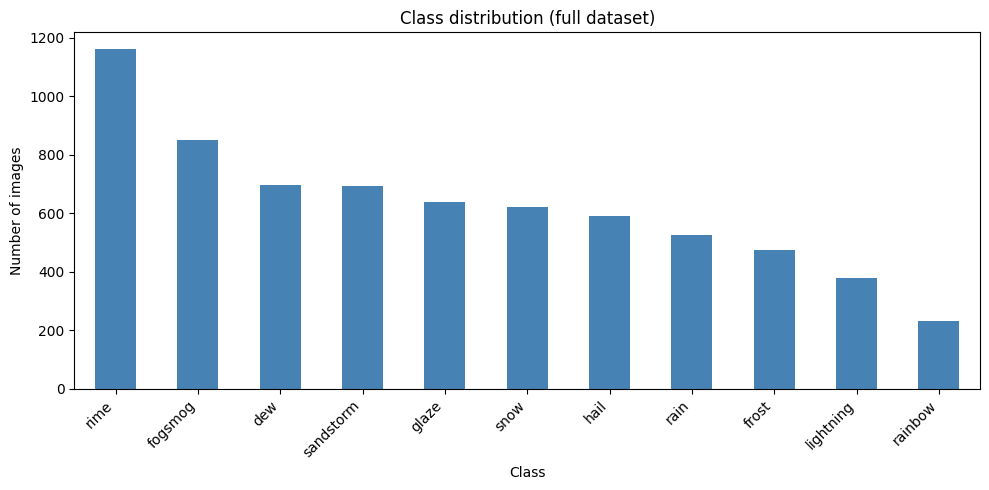

label
rime         1160
fogsmog       851
dew           698
sandstorm     692
glaze         639
snow          621
hail          591
rain          526
frost         475
lightning     377
rainbow       232
Name: count, dtype: int64

Imbalance ratio (largest class / smallest class): 5.00x


In [5]:
class_counts = df["label"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
class_counts.plot(kind="bar", color="steelblue")
plt.title("Class distribution (full dataset)")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(class_counts)
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (largest class / smallest class): {imbalance_ratio:.2f}x")


## 4. Stratified train / validation / test split

Because the dataset is imbalanced, a plain random split can easily leave a rare class
under-represented (or even entirely absent) in the validation or test set, which would make our
evaluation metrics unreliable for that class.

**Stratified sampling** solves this: we split the data so that *every* split (train, val, test)
preserves the same class proportions as the original dataset. `sklearn.model_selection.
train_test_split` does this for us via the `stratify` argument.

We do this in two steps:
1. Split off 70% train / 30% temp (stratified on `label`).
2. Split the 30% temp into 15% val / 15% test (stratified on `label` again).

We also apply two complementary fixes for the imbalance during training:
- **Stratified splitting** (this section) — makes sure every split is representative.
- **Class-weighted loss** (Section 6) — makes sure the model doesn't just learn to predict the
  majority classes to minimize loss.

In [6]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} images ({len(train_df) / len(df):.1%})")
print(f"Val:   {len(val_df)} images ({len(val_df) / len(df):.1%})")
print(f"Test:  {len(test_df)} images ({len(test_df) / len(df):.1%})")


Train: 4803 images (70.0%)
Val:   1029 images (15.0%)
Test:  1030 images (15.0%)


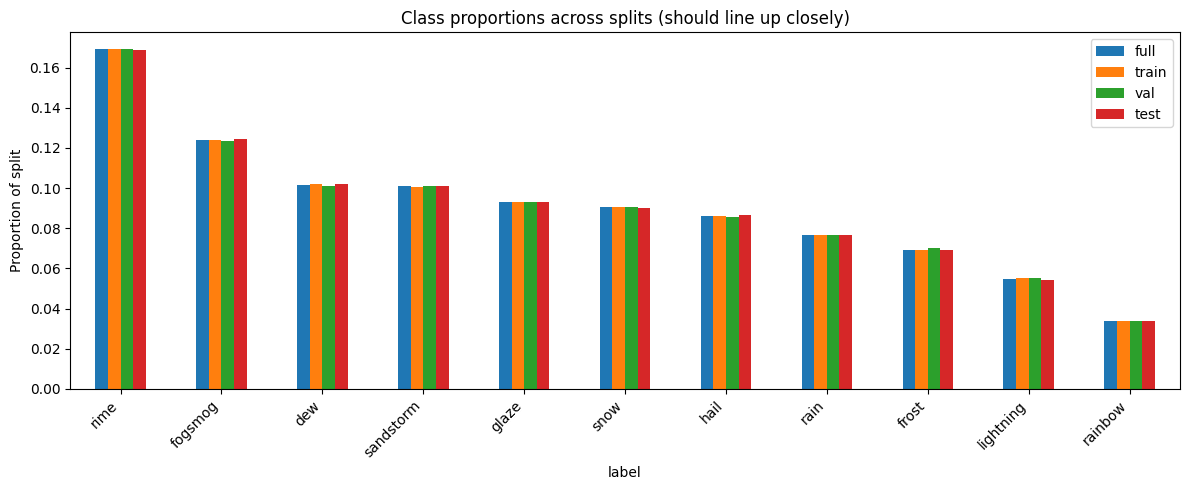

,full,train,val,test
label,,,,
rime,0.169,0.169,0.169,0.169
fogsmog,0.124,0.124,0.123,0.124
dew,0.102,0.102,0.101,0.102
sandstorm,0.101,0.101,0.101,0.101
glaze,0.093,0.093,0.093,0.093
snow,0.090,0.091,0.090,0.090
hail,0.086,0.086,0.086,0.086
rain,0.077,0.077,0.077,0.077
frost,0.069,0.069,0.070,0.069


In [7]:
# Sanity check: class proportions should be (almost) identical across splits
proportions = pd.DataFrame({
    "full": df["label"].value_counts(normalize=True),
    "train": train_df["label"].value_counts(normalize=True),
    "val": val_df["label"].value_counts(normalize=True),
    "test": test_df["label"].value_counts(normalize=True),
}).sort_values("full", ascending=False)

proportions.plot(kind="bar", figsize=(12, 5))
plt.title("Class proportions across splits (should line up closely)")
plt.ylabel("Proportion of split")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

proportions.round(3)


## 5. A custom `Dataset` class

`WeatherDataset` wraps one of our DataFrames (`train_df`, `val_df`, or `test_df`). For each
index it:
1. Reads the image from disk and converts it to RGB (some JPGs are grayscale or CMYK, which
   would break a model expecting 3 channels).
2. Looks up the integer label for the class name.
3. Applies the given `transform` (augmentation for training, deterministic resize/crop for
   evaluation — defined next).

Keeping the Dataset generic like this (just "give me a DataFrame + a transform") lets us reuse
the exact same class for train/val/test, and even for the different fine-tuning stages later,
without duplicating any logic.

In [8]:
class WeatherDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        label = self.class_to_idx[row["label"]]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


### Transforms

Because we are reusing a network pretrained on ImageNet, our images must be preprocessed
**exactly the way ImageNet images were** during that pretraining, otherwise the pretrained
filters will be looking at inputs with a completely different statistical distribution than
what they learned on:

- Resize/crop to `224x224`.
- Scale pixel values to `[0, 1]` (`ToTensor`).
- Normalize each channel with ImageNet's mean/std: `mean=[0.485, 0.456, 0.406]`,
  `std=[0.229, 0.224, 0.225]`.

For **training**, we add light data augmentation (`RandomResizedCrop`, horizontal flip, color
jitter) since our dataset is small and augmentation acts as a cheap regularizer. For
**validation/test**, we use a deterministic resize + center-crop only — we want a stable,
repeatable evaluation, not a randomly-augmented one.

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),   # 256 for a 224 crop, same ratio ImageNet uses
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = WeatherDataset(train_df, class_to_idx, transform=train_transform)
val_dataset = WeatherDataset(val_df, class_to_idx, transform=eval_transform)
test_dataset = WeatherDataset(test_df, class_to_idx, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

dataloaders = {"train": train_loader, "val": val_loader}
dataset_sizes = {"train": len(train_dataset), "val": len(val_dataset)}

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}  "
      f"Test batches: {len(test_loader)}")


Train batches: 151  Val batches: 33  Test batches: 33


### Class weights for the loss function

Stratified splitting keeps every split *representative*, but the training set itself is still
imbalanced — the model will still see far more examples of common classes than rare ones each
epoch. To stop the model from just defaulting to majority classes, we compute an
**inverse-frequency class weight** and pass it to `CrossEntropyLoss`. This makes mistakes on
rare classes cost proportionally more than mistakes on common ones.

In [10]:
class_sample_counts = train_df["label"].value_counts().reindex(CLASSES).values
class_weights = 1.0 / class_sample_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES  # normalize, avg weight ~= 1
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"{'Class':12s} {'#train imgs':>12s} {'loss weight':>12s}")
for c, n, w in zip(CLASSES, class_sample_counts, class_weights):
    print(f"{c:12s} {n:12d} {w:12.3f}")


Class         #train imgs  loss weight
dew                   489        0.758
fogsmog               596        0.622
frost                 332        1.117
glaze                 447        0.830
hail                  414        0.896
lightning             264        1.405
rain                  368        1.008
rainbow               162        2.289
rime                  812        0.457
sandstorm             484        0.766
snow                  435        0.853


## 6. Loading ResNet-34 & visualizing `conv1` before/after pretraining

Before we touch training, let's actually *look* at what pretraining gives us. ResNet-34's very
first layer, `conv1`, is a `7x7` convolution with 64 output filters applied directly to the
RGB input. These filters are small enough to visualize directly as tiny RGB images.

We load two versions of the exact same architecture:
1. `weights=None` — random initialization (this is what our Lecture-1 custom CNN effectively
   started from).
2. `weights=ResNet34_Weights.IMAGENET1K_V1` — the official torchvision weights trained on
   ImageNet-1K.

Then we plot the first 16 `conv1` filters from each. You should see a clear qualitative
difference: the randomly-initialized filters look like unstructured noise, while the
ImageNet-pretrained filters have visibly learned structure — edge detectors at various
orientations, color-opponent blobs, and simple texture detectors. This is exactly the kind of
general-purpose, low-level visual vocabulary that transfer learning lets us reuse for free.

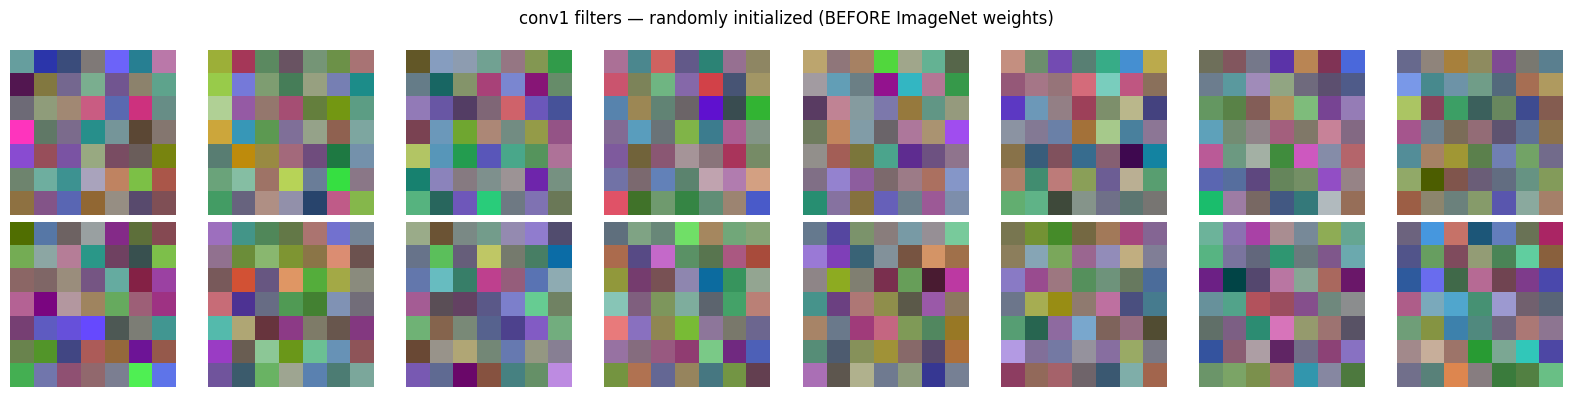

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 189MB/s]


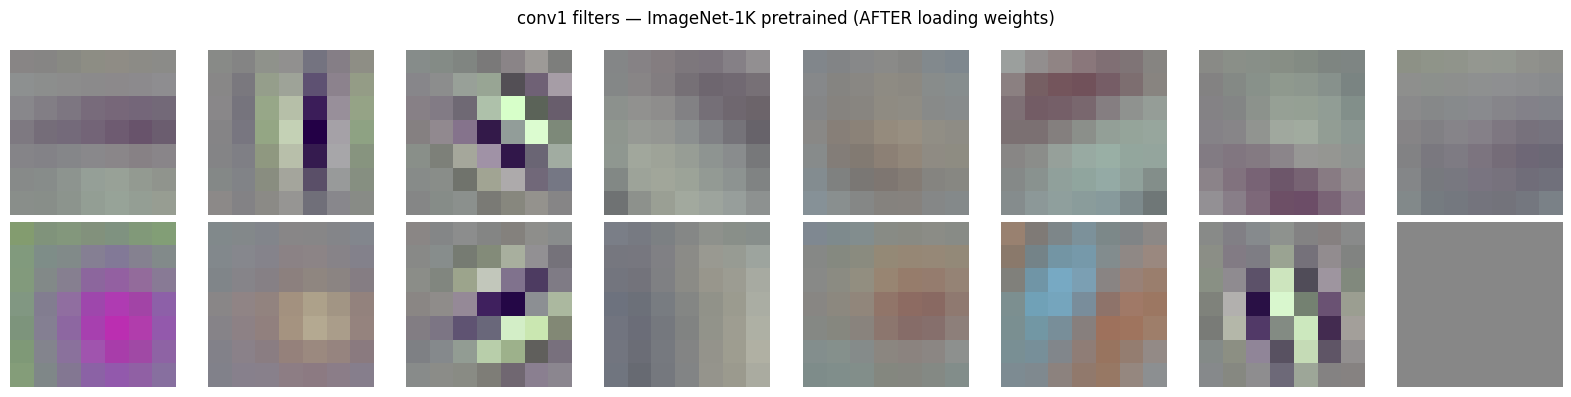

In [11]:
def get_conv1_weights(model):
    return model.conv1.weight.data.clone().cpu()


def visualize_conv1_filters(weights, title, n_filters=16):
    w = weights[:n_filters].clone()
    w_min, w_max = w.min(), w.max()
    w = (w - w_min) / (w_max - w_min + 1e-8)  # normalize to [0, 1] for display

    n_cols = 8
    n_rows = int(np.ceil(n_filters / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
    fig.suptitle(title)
    for i, ax in enumerate(axes.flat):
        if i < w.shape[0]:
            img = w[i].permute(1, 2, 0).numpy()
            ax.imshow(img)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


model_random = models.resnet34(weights=None)
conv1_random = get_conv1_weights(model_random)
visualize_conv1_filters(conv1_random, "conv1 filters \u2014 randomly initialized (BEFORE ImageNet weights)")

model_pretrained = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
conv1_pretrained = get_conv1_weights(model_pretrained)
visualize_conv1_filters(conv1_pretrained, "conv1 filters \u2014 ImageNet-1K pretrained (AFTER loading weights)")

del model_random, model_pretrained  # free memory, we'll build fresh copies for each stage


## 7. Reusable training & evaluation functions

To keep the three fine-tuning stages below clean and comparable, we write the training loop and
evaluation logic **once** and reuse them for every stage. We only ever change: which parameters
are frozen/unfrozen, and the optimizer's learning rates.

- `build_resnet34(num_classes, pretrained)` — loads ResNet-34 and replaces the final fully
  connected layer (`fc`) with a fresh `Linear` layer sized for our number of classes. The
  original `fc` was a `512 -> 1000` layer for ImageNet; ours is `512 -> NUM_CLASSES`. This new
  layer is **always** randomly initialized and **always** trainable — it's the one part of the
  network that must be trained from scratch, since our classes don't exist in ImageNet.
- `train_model(...)` — a standard PyTorch train/val loop that tracks loss & accuracy per epoch,
  keeps the best-performing weights (by validation accuracy), and returns the trained model plus
  a history dict for plotting.
- `plot_history(...)` — plots the loss and accuracy curves for a given stage.
- `evaluate_model(...)` — runs the model on a held-out loader (our test set) and reports
  accuracy, macro-averaged precision/recall/F1, a full per-class `classification_report`, and a
  confusion matrix heatmap. We use **macro averaging** (unweighted mean across classes) rather
  than the default micro/weighted averaging specifically *because* our classes are imbalanced —
  macro averaging makes sure a rare class contributes just as much to the reported score as a
  common one, so we can't hide poor performance on rare classes behind good performance on
  common ones.

In [12]:
def build_resnet34(num_classes, pretrained=True):
    weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.resnet34(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


In [13]:
def train_model(model, dataloaders, dataset_sizes, criterion, optimizer,
                 scheduler=None, num_epochs=5, stage_name="stage"):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        print(f"\n[{stage_name}] Epoch {epoch + 1}/{num_epochs}")
        print("-" * 40)

        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == "train" and scheduler is not None:
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            print(f"{phase:5s} | loss: {epoch_loss:.4f}  acc: {epoch_acc:.4f}")

            if phase == "val" and epoch_acc > best_val_acc:
                best_val_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    elapsed = time.time() - since
    print(f"\n[{stage_name}] Training complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
    print(f"[{stage_name}] Best validation accuracy: {best_val_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="train", marker="o")
    axes[0].plot(history["val_loss"], label="val", marker="o")
    axes[0].set_title(f"{title} \u2014 Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="train", marker="o")
    axes[1].plot(history["val_acc"], label="val", marker="o")
    axes[1].set_title(f"{title} \u2014 Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [14]:
def evaluate_model(model, dataloader, class_names, title="Evaluation"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    print(f"=== {title} ===")
    print(f"Accuracy:           {acc:.4f}")
    print(f"Precision (macro):  {precision:.4f}")
    print(f"Recall (macro):     {recall:.4f}")
    print(f"F1-score (macro):   {f1:.4f}\n")

    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{title} \u2014 Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


## 8. Stage 1 — Feature extraction: train only the classification head

This is the simplest and cheapest form of transfer learning. We treat the pretrained ResNet-34
as a **fixed feature extractor**:

- Load ImageNet weights.
- Replace `fc` with a new, randomly-initialized `Linear(512, NUM_CLASSES)`.
- **Freeze every parameter except `fc`** (`requires_grad = False` on everything else), so
  gradients are never computed or applied for the backbone.
- Train with a single, relatively large learning rate on just the head's parameters.

Because we're only training a small linear layer on top of already-good, frozen features, this
is fast, needs little data, and is very unlikely to overfit — but it also caps our ceiling: the
backbone's features were tuned for ImageNet's 1000 object classes, not specifically for
distinguishing "frost" from "glaze" or "fogsmog" from "haze"-like weather patterns.

Trainable parameters: 5,643 / 21,290,315 (0.03% of the network)

[Stage 1 - head only] Epoch 1/5
----------------------------------------
train | loss: 1.1878  acc: 0.6602
val   | loss: 0.6882  acc: 0.7979

[Stage 1 - head only] Epoch 2/5
----------------------------------------
train | loss: 0.6094  acc: 0.8110
val   | loss: 0.5235  acc: 0.8241

[Stage 1 - head only] Epoch 3/5
----------------------------------------
train | loss: 0.5129  acc: 0.8332
val   | loss: 0.4746  acc: 0.8260

[Stage 1 - head only] Epoch 4/5
----------------------------------------
train | loss: 0.4525  acc: 0.8511
val   | loss: 0.4345  acc: 0.8435

[Stage 1 - head only] Epoch 5/5
----------------------------------------
train | loss: 0.4269  acc: 0.8543
val   | loss: 0.4214  acc: 0.8377

[Stage 1 - head only] Training complete in 3m 53s
[Stage 1 - head only] Best validation accuracy: 0.8435


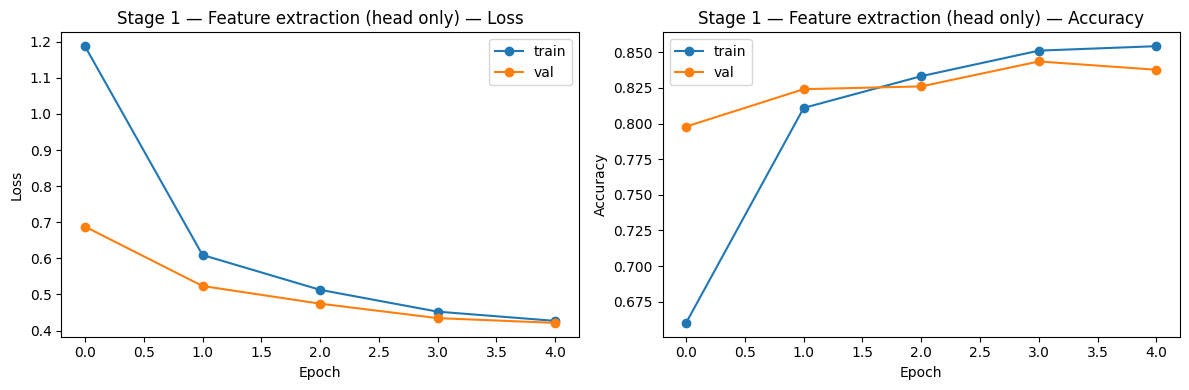

In [15]:
model_stage1 = build_resnet34(NUM_CLASSES, pretrained=True)

for name, param in model_stage1.named_parameters():
    param.requires_grad = "fc" in name

n_trainable = sum(p.numel() for p in model_stage1.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model_stage1.parameters())
print(f"Trainable parameters: {n_trainable:,} / {n_total:,} "
      f"({n_trainable / n_total:.2%} of the network)")

model_stage1 = model_stage1.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer_stage1 = optim.Adam(model_stage1.fc.parameters(), lr=1e-3)

EPOCHS_STAGE1 = 5  # small demo value for a live lecture - raise this for better results

model_stage1, history_stage1 = train_model(
    model_stage1, dataloaders, dataset_sizes, criterion, optimizer_stage1,
    scheduler=None, num_epochs=EPOCHS_STAGE1, stage_name="Stage 1 - head only",
)
plot_history(history_stage1, "Stage 1 \u2014 Feature extraction (head only)")


=== Stage 1 - Head only (Test set) ===
Accuracy:           0.8641
Precision (macro):  0.8680
Recall (macro):     0.8675
F1-score (macro):   0.8656

              precision    recall  f1-score   support

         dew       0.93      0.95      0.94       105
     fogsmog       0.83      0.88      0.85       128
       frost       0.76      0.80      0.78        71
       glaze       0.86      0.69      0.76        96
        hail       0.92      0.99      0.95        89
   lightning       0.96      0.98      0.97        56
        rain       0.87      0.78      0.83        79
     rainbow       0.91      0.91      0.91        35
        rime       0.94      0.87      0.90       174
   sandstorm       0.91      0.88      0.89       104
        snow       0.66      0.81      0.72        93

    accuracy                           0.86      1030
   macro avg       0.87      0.87      0.87      1030
weighted avg       0.87      0.86      0.86      1030



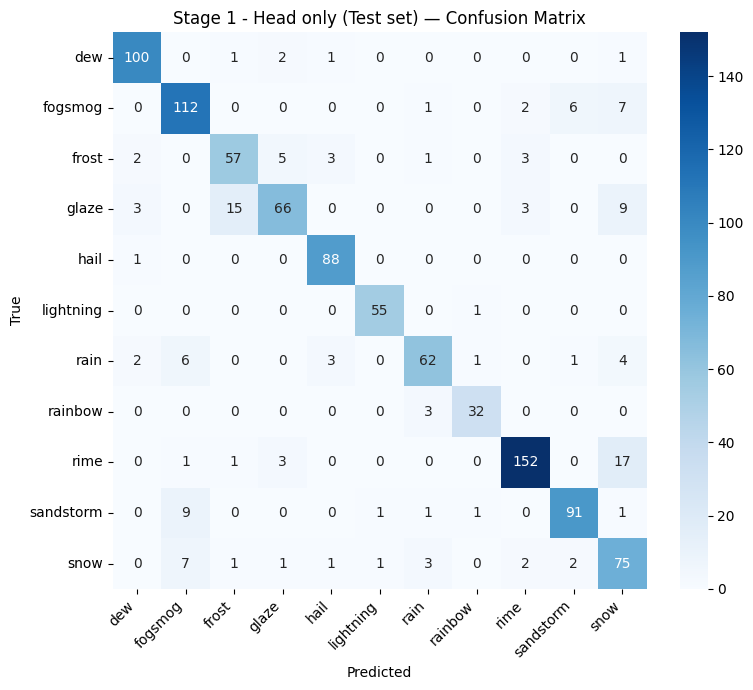

In [16]:
results_stage1 = evaluate_model(
    model_stage1, test_loader, CLASSES, title="Stage 1 - Head only (Test set)"
)


## 9. Stage 2 — Partial fine-tuning with differential learning rates

Now we let the network adapt some of its higher-level features to our task. In a ResNet, the
layers are organized (from input to output) as `conv1/bn1 -> layer1 -> layer2 -> layer3 ->
layer4 -> fc`. The earlier layers (`conv1`, `layer1`) learn very generic features (edges,
colors, textures) that transfer well across almost any image task, while the later layers
(`layer3`, `layer4`) learn increasingly task-specific, high-level features (object parts,
shapes) that benefit the most from adapting to a new domain.

So for partial fine-tuning we:
- Keep `conv1`, `bn1`, `layer1`, `layer2`, `layer3` **frozen**.
- **Unfreeze `layer4`** (the last residual block group) and the new `fc` head.
- Use **two different learning rates** in a single optimizer via PyTorch parameter groups: a
  small one for `layer4` (it's already reasonably good, we only want to nudge it) and a much
  larger one for `fc` (it's randomly initialized and needs to learn fast). This is the essence
  of **differential/discriminative learning rates**: different parts of the network are treated
  differently based on how much they need to change.

Trainable parameters: 13,120,011 / 21,290,315 (61.62% of the network)  -> layer4 + fc

[Stage 2 - partial unfreeze] Epoch 1/5
----------------------------------------
train | loss: 0.9567  acc: 0.7085
val   | loss: 0.4449  acc: 0.8591

[Stage 2 - partial unfreeze] Epoch 2/5
----------------------------------------
train | loss: 0.4054  acc: 0.8643
val   | loss: 0.3354  acc: 0.8707

[Stage 2 - partial unfreeze] Epoch 3/5
----------------------------------------
train | loss: 0.3011  acc: 0.8949
val   | loss: 0.3028  acc: 0.8805

[Stage 2 - partial unfreeze] Epoch 4/5
----------------------------------------
train | loss: 0.2550  acc: 0.9061
val   | loss: 0.2926  acc: 0.8853

[Stage 2 - partial unfreeze] Epoch 5/5
----------------------------------------
train | loss: 0.2058  acc: 0.9234
val   | loss: 0.2843  acc: 0.8970

[Stage 2 - partial unfreeze] Training complete in 2m 43s
[Stage 2 - partial unfreeze] Best validation accuracy: 0.8970


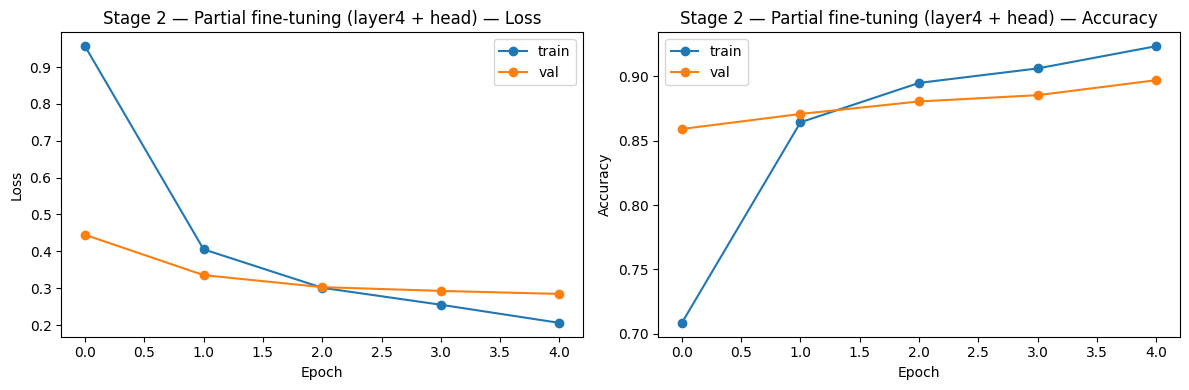

In [17]:
model_stage2 = build_resnet34(NUM_CLASSES, pretrained=True)

for param in model_stage2.parameters():
    param.requires_grad = False
for param in model_stage2.layer4.parameters():
    param.requires_grad = True
for param in model_stage2.fc.parameters():
    param.requires_grad = True

n_trainable = sum(p.numel() for p in model_stage2.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model_stage2.parameters())
print(f"Trainable parameters: {n_trainable:,} / {n_total:,} "
      f"({n_trainable / n_total:.2%} of the network)  -> layer4 + fc")

model_stage2 = model_stage2.to(device)

optimizer_stage2 = optim.Adam([
    {"params": model_stage2.layer4.parameters(), "lr": 1e-5},  # small LR: already good features
    {"params": model_stage2.fc.parameters(),      "lr": 1e-3}, # large LR: freshly initialized
])

EPOCHS_STAGE2 = 5

model_stage2, history_stage2 = train_model(
    model_stage2, dataloaders, dataset_sizes, criterion, optimizer_stage2,
    scheduler=None, num_epochs=EPOCHS_STAGE2, stage_name="Stage 2 - partial unfreeze",
)
plot_history(history_stage2, "Stage 2 \u2014 Partial fine-tuning (layer4 + head)")


=== Stage 2 - Partial unfreeze (Test set) ===
Accuracy:           0.9010
Precision (macro):  0.9028
Recall (macro):     0.8990
F1-score (macro):   0.8997

              precision    recall  f1-score   support

         dew       0.96      0.93      0.95       105
     fogsmog       0.90      0.95      0.92       128
       frost       0.84      0.82      0.83        71
       glaze       0.88      0.80      0.84        96
        hail       0.95      0.97      0.96        89
   lightning       0.96      0.98      0.97        56
        rain       0.82      0.91      0.86        79
     rainbow       0.94      0.89      0.91        35
        rime       0.93      0.92      0.92       174
   sandstorm       0.99      0.86      0.92       104
        snow       0.77      0.87      0.82        93

    accuracy                           0.90      1030
   macro avg       0.90      0.90      0.90      1030
weighted avg       0.90      0.90      0.90      1030



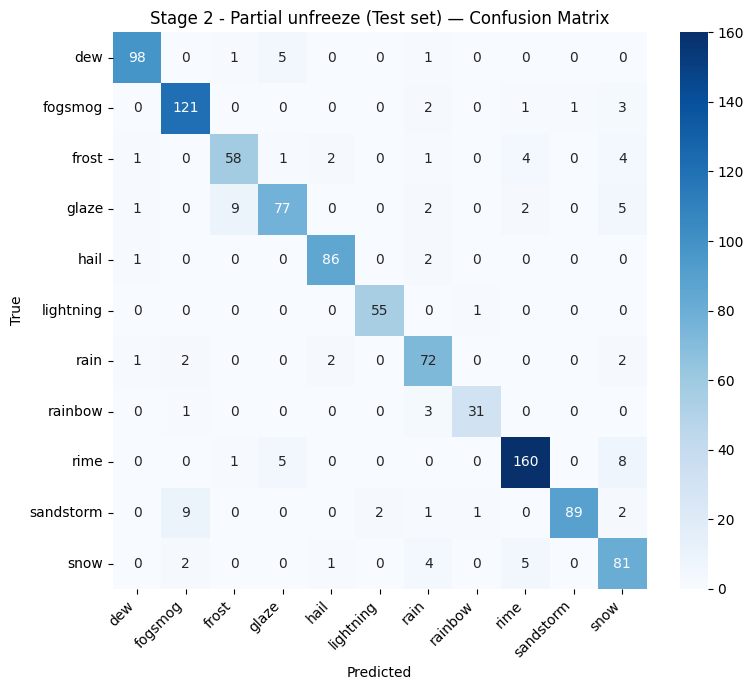

In [18]:
results_stage2 = evaluate_model(
    model_stage2, test_loader, CLASSES, title="Stage 2 - Partial unfreeze (Test set)"
)


## 10. Stage 3 — Full fine-tuning with differential learning rates across all layers

Finally, we unfreeze the **entire** network. This gives the model the most flexibility to adapt
to our weather images, but also the most risk: with a small dataset, aggressively fine-tuning
early layers can destroy the general-purpose features they learned from ImageNet
("catastrophic forgetting"), actually *hurting* performance.

The standard fix is to extend the differential-learning-rate idea from Stage 2 across the
**whole** network: give every layer group its own learning rate, increasing from the earliest
layers (tiny LR — barely move these, they're already very general) to the latest layers and
head (larger LR — these should adapt the most). We also add a `StepLR` scheduler that decays all
of these learning rates together as training progresses, so the whole network settles down as it
converges instead of continuing to take large steps.

Trainable parameters: 21,290,315 / 21,290,315 (100.00% of the network)  -> entire network

[Stage 3 - full fine-tune] Epoch 1/6
----------------------------------------
train | loss: 0.6538  acc: 0.7876
val   | loss: 0.2940  acc: 0.8912

[Stage 3 - full fine-tune] Epoch 2/6
----------------------------------------
train | loss: 0.2434  acc: 0.9144
val   | loss: 0.2723  acc: 0.8999

[Stage 3 - full fine-tune] Epoch 3/6
----------------------------------------
train | loss: 0.1481  acc: 0.9463
val   | loss: 0.2923  acc: 0.9009

[Stage 3 - full fine-tune] Epoch 4/6
----------------------------------------
train | loss: 0.0874  acc: 0.9663
val   | loss: 0.2815  acc: 0.9145

[Stage 3 - full fine-tune] Epoch 5/6
----------------------------------------
train | loss: 0.0662  acc: 0.9748
val   | loss: 0.2824  acc: 0.9116

[Stage 3 - full fine-tune] Epoch 6/6
----------------------------------------
train | loss: 0.0528  acc: 0.9796
val   | loss: 0.2826  acc: 0.9145

[Stage 3 - full fine-tune] 

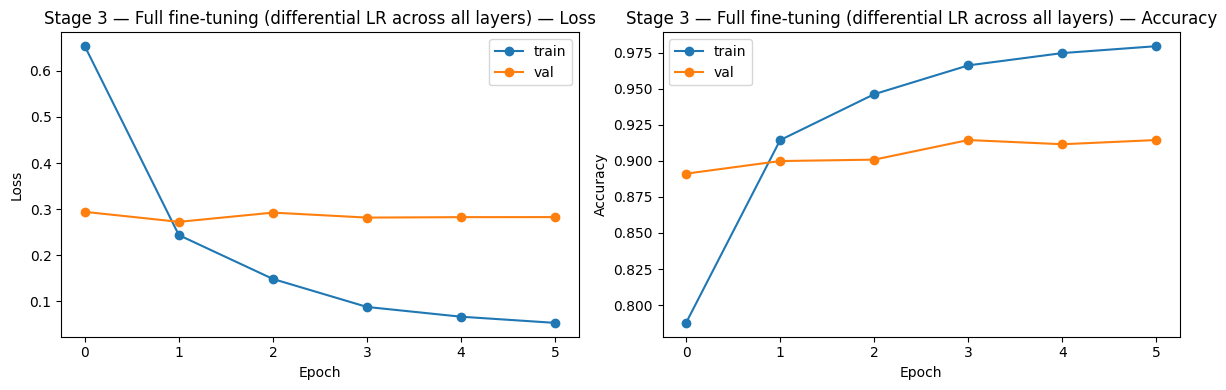

In [19]:
model_stage3 = build_resnet34(NUM_CLASSES, pretrained=True)

for param in model_stage3.parameters():
    param.requires_grad = True

n_trainable = sum(p.numel() for p in model_stage3.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model_stage3.parameters())
print(f"Trainable parameters: {n_trainable:,} / {n_total:,} "
      f"({n_trainable / n_total:.2%} of the network)  -> entire network")

model_stage3 = model_stage3.to(device)

# Learning rate increases the closer we get to the output (head), the smaller it is
# for early, general-purpose layers.
optimizer_stage3 = optim.Adam([
    {"params": model_stage3.conv1.parameters(),  "lr": 1e-6},
    {"params": model_stage3.bn1.parameters(),    "lr": 1e-6},
    {"params": model_stage3.layer1.parameters(), "lr": 1e-6},
    {"params": model_stage3.layer2.parameters(), "lr": 5e-6},
    {"params": model_stage3.layer3.parameters(), "lr": 1e-5},
    {"params": model_stage3.layer4.parameters(), "lr": 5e-5},
    {"params": model_stage3.fc.parameters(),     "lr": 1e-3},
])

scheduler_stage3 = lr_scheduler.StepLR(optimizer_stage3, step_size=3, gamma=0.5)

EPOCHS_STAGE3 = 6

model_stage3, history_stage3 = train_model(
    model_stage3, dataloaders, dataset_sizes, criterion, optimizer_stage3,
    scheduler=scheduler_stage3, num_epochs=EPOCHS_STAGE3, stage_name="Stage 3 - full fine-tune",
)
plot_history(history_stage3, "Stage 3 \u2014 Full fine-tuning (differential LR across all layers)")


=== Stage 3 - Full fine-tune (Test set) ===
Accuracy:           0.9204
Precision (macro):  0.9278
Recall (macro):     0.9238
F1-score (macro):   0.9248

              precision    recall  f1-score   support

         dew       0.95      0.97      0.96       105
     fogsmog       0.92      0.95      0.94       128
       frost       0.90      0.80      0.85        71
       glaze       0.79      0.90      0.84        96
        hail       0.95      0.98      0.96        89
   lightning       1.00      1.00      1.00        56
        rain       0.93      0.90      0.92        79
     rainbow       1.00      0.94      0.97        35
        rime       0.94      0.87      0.91       174
   sandstorm       0.97      0.94      0.96       104
        snow       0.84      0.90      0.87        93

    accuracy                           0.92      1030
   macro avg       0.93      0.92      0.92      1030
weighted avg       0.92      0.92      0.92      1030



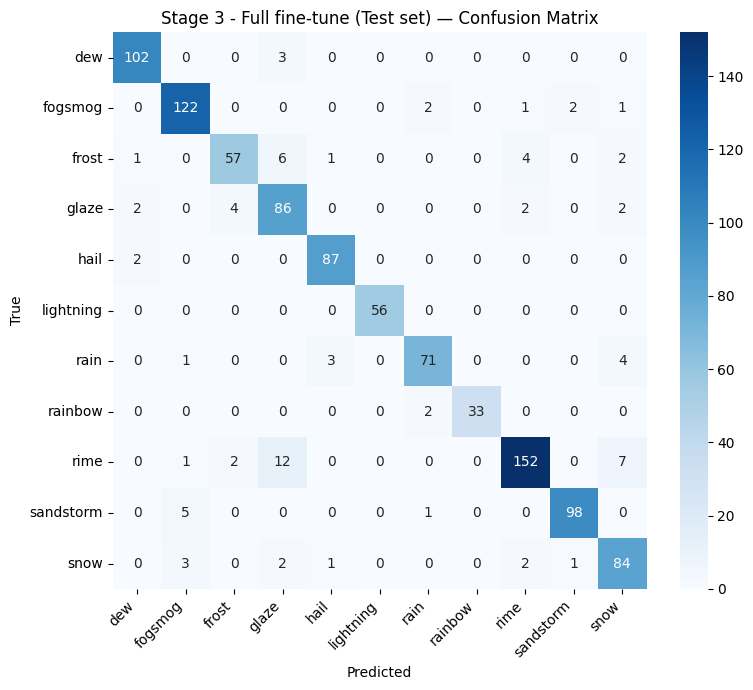

In [20]:
results_stage3 = evaluate_model(
    model_stage3, test_loader, CLASSES, title="Stage 3 - Full fine-tune (Test set)"
)


## 11. Revisiting `conv1` after full fine-tuning

Now that `conv1` was allowed to update (with a very small learning rate) during Stage 3, let's
look at it again next to the original ImageNet weights. With a small learning rate and a small
number of epochs, we expect the filters to look only **slightly** different from the pretrained
ones — small, task-specific nudges rather than a complete change. If you trained Stage 3 with a
much higher learning rate on the early layers, you'd likely see these filters degrade back
towards noise — a visual example of catastrophic forgetting.

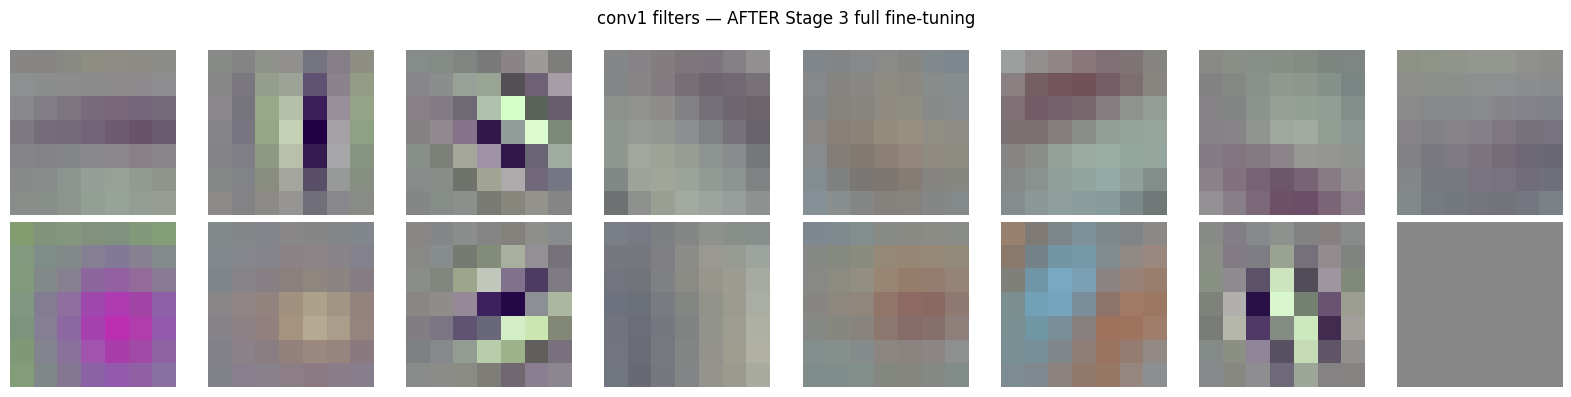

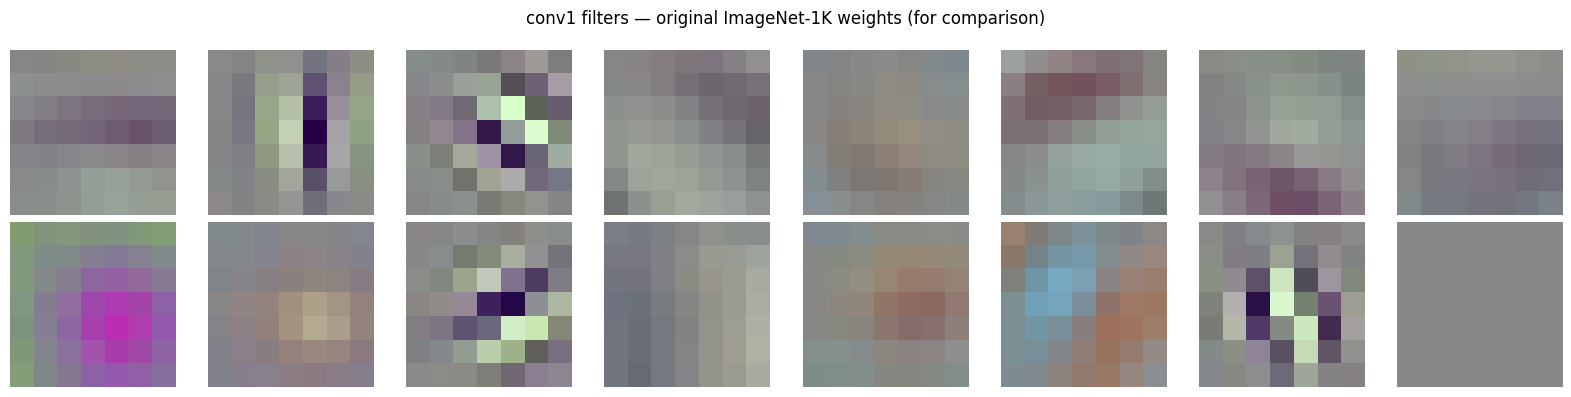

In [21]:
conv1_after_finetune = get_conv1_weights(model_stage3)
visualize_conv1_filters(
    conv1_after_finetune,
    "conv1 filters \u2014 AFTER Stage 3 full fine-tuning",
)
visualize_conv1_filters(
    conv1_pretrained,
    "conv1 filters \u2014 original ImageNet-1K weights (for comparison)",
)


## 12. Comparing all three strategies

Finally, let's put the test-set metrics from all three stages side by side. There's no single
"always correct" choice between feature extraction, partial fine-tuning, and full fine-tuning —
the right strategy depends on:

- **How similar** your task is to ImageNet (weather photos are still natural photographs, so
  even frozen ImageNet features transfer reasonably well).
- **How much data** you have (more data can support unfreezing more of the network without
  overfitting).
- **Compute budget** (feature extraction is by far the cheapest; full fine-tuning is the most
  expensive per epoch and typically needs more epochs and careful learning rates to pay off).

Look at the table and plots below and discuss with the class: did unfreezing more of the network
actually help on *this* dataset, or did feature extraction alone get most of the benefit?

In [22]:
comparison_df = pd.DataFrame([
    {"Stage": "1. Head only", **results_stage1},
    {"Stage": "2. Partial unfreeze (layer4 + head)", **results_stage2},
    {"Stage": "3. Full fine-tune (all layers)", **results_stage3},
]).set_index("Stage")

display(comparison_df.style.format("{:.4f}").background_gradient(cmap="Greens"))


,accuracy,precision,recall,f1
Stage,,,,
1. Head only,0.8641,0.8680,0.8675,0.8656
2. Partial unfreeze (layer4 + head),0.9010,0.9028,0.8990,0.8997
3. Full fine-tune (all layers),0.9204,0.9278,0.9238,0.9248


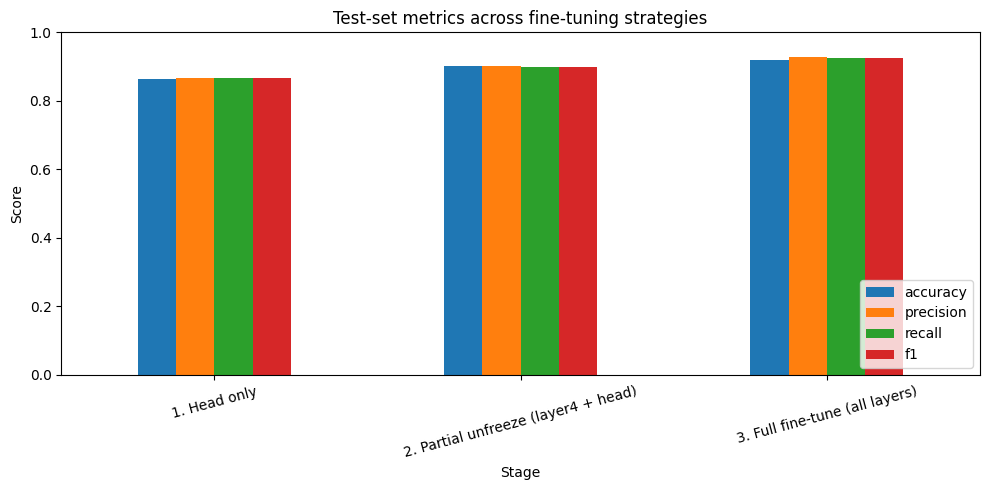

In [23]:
comparison_df.plot(kind="bar", figsize=(10, 5), rot=15)
plt.title("Test-set metrics across fine-tuning strategies")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 13. Summary

- **Transfer learning** lets us reuse features learned from a huge dataset (ImageNet-1K) on a
  small dataset like ours, dramatically reducing the amount of data and training time needed
  compared to training from scratch (Lecture 1).
- **Feature extraction** (Stage 1) is fast and low-risk, but caps performance at what the frozen
  ImageNet features can express for our task.
- **Partial fine-tuning** (Stage 2) unfreezes the later, more task-specific layers, using a
  small learning rate for them and a larger one for the head — this is **differential learning
  rates** applied to two groups.
- **Full fine-tuning** (Stage 3) extends differential learning rates across every layer group,
  from tiny (early, general layers) to large (late layers and head), balancing adaptation
  against the risk of catastrophic forgetting.
- We handled **class imbalance** two ways: **stratified splitting** (so every split is
  representative) and a **class-weighted loss** (so training doesn't just favor majority
  classes).
- We evaluated every stage with **accuracy, macro precision, macro recall, and macro F1**, plus
  a full classification report and confusion matrix per stage, specifically so that performance
  on rare classes is visible rather than hidden behind strong majority-class performance.

**Next lecture:** we'll look at more advanced fine-tuning tricks — learning rate warm-up,
gradual unfreezing (unfreeze one layer group at a time across epochs), and mixed-precision
training to speed all of this up.